<a href="https://colab.research.google.com/github/abxda/INFOTEC-Aprendizaje-No-Supervisado/blob/main/Semana7_Actividad_Solucion.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Semana 7 — Visualización de Datos en Alta Dimensión
## Pipeline Integral: UMAP + Detección de Anomalías + Clustering + Nubes de Palabras

**Materia:** Aprendizaje No Supervisado — INFOTEC  
**Instructor:** Dr. Coronado  
**Actividad:** Seguir los pasos del documento `01-visualizacion.pdf` (Prof. Guillermo Ruiz)  

---

### Objetivo de la actividad

En esta sesión integramos **todas las herramientas** que hemos construido a lo largo del curso en un pipeline de análisis completo. Trabajaremos con un conjunto real de **20,000 tweets mexicanos** que fueron convertidos en vectores de 768 dimensiones mediante un modelo de lenguaje.

| Semana | Concepto | Rol en esta actividad |
|--------|----------|-----------------------|
| 1 | K-Means | Referencia de clustering por centroides |
| 2 | DBSCAN | Agrupamiento por densidad + ruido como anomalías |
| 3 | HDBSCAN / Silhouette | Clustering jerárquico adaptativo |
| 4 | PCA / t-SNE | Reducción de dimensionalidad → hoy usamos UMAP |
| 5 | Autoencoders / Embeddings | Los vectores que analizamos **son** embeddings |
| 6 | Detección de Anomalías | OC-SVM con `decision_function` → limpieza |

### Los 5 entregables

1. **Proyección a 2D** de los datos (UMAP)
2. **Identificación de anomalías** (One-Class SVM + `decision_function`)
3. **Proyección a 2D sin anomalías**
4. **Datos en 2D separados en clusters** (HDBSCAN)
5. **4 nubes de palabras** para algunos clusters, identificando el tipo de textos

---
## Paso 0 — Instalación de dependencias


> **¿Por qué estas librerías?**
> - `umap-learn`: Implementa UMAP, el sucesor moderno de t-SNE para proyecciones 2D (evolución de lo visto en Semana 4).
> - `hdbscan`: Clustering jerárquico por densidad — no requiere fijar número de clusters (evolución de Semanas 1-3).
> - `wordcloud`: Generación de nubes de palabras para interpretar clusters de texto.

In [1]:
# Descomentar en Google Colab:
!pip install umap-learn hdbscan wordcloud -q

---
## Paso 1 — Importaciones

Organizamos las importaciones por categoría funcional. Cada bloque corresponde a una fase del pipeline y a una semana específica del curso.

In [2]:
# ── Manejo de datos ──────────────────────────────────────────────
import numpy as np
import pandas as pd

# ── Visualización ────────────────────────────────────────────────
import matplotlib.pyplot as plt
import seaborn as sns

# ── Reducción de dimensionalidad (Semana 4 → evolución) ────────
import umap

# ── Detección de anomalías (Semana 6 → aplicación) ─────────────
from sklearn.svm import OneClassSVM

# ── Clustering (Semanas 1-3 → integración) ─────────────────────
import hdbscan

# ── Nubes de palabras ─────────────────────────────────────────
from wordcloud import WordCloud

# ── Configuración visual ──────────────────────────────────────
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 7)
plt.rcParams['figure.dpi'] = 100

import warnings
warnings.filterwarnings('ignore')

import re
from collections import Counter

print('Todas las librerías cargadas correctamente.')

Todas las librerías cargadas correctamente.


---
## Paso 2 — Carga de datos

### ¿Qué contienen estos archivos?

Trabajamos con el dataset proporcionado por el Prof. Guillermo Ruiz en `01-visualizacion.pdf`:

- **`encajes.npy`**: Matriz de (20,000 × 768). Cada fila es un **embedding** — un vector denso de 768 dimensiones que codifica el significado semántico de un tweet. Estos vectores fueron generados por un modelo de lenguaje (tipo BERT), que comprimió todo el contenido del texto en una representación numérica.

- **`small_df.csv`**: DataFrame con dos columnas: `text` (el tweet original) y `label` (un emoji que categoriza el tono/emoción del mensaje).

> **Conexión con Semana 5 (Autoencoders):** Recuerden que un **embedding** es la *coordenada* de un dato en un *espacio latente*. Así como nuestro autoencoder comprimía imágenes MNIST a un vector de pocas dimensiones, el modelo de lenguaje comprimió cada tweet a un vector de 768 dimensiones que captura su esencia semántica. Dos tweets con significado similar tendrán vectores cercanos, aunque usen palabras diferentes.

In [3]:
# ── Carga del conjunto de vectores y textos ────────────────────
X = np.load('encajes.npy')
X.shape

(20000, 768)

In [8]:
df = pd.read_csv('small_df.csv')
df.head()

,text,label
0,Mi turbo carnala del alma _USR _emo👊🏼 en La Pl...,😎
1,Las chicas de *Jimmy's* te esperan para pasar ...,😍
2,Big Time Rush y Mario Casas me quieren matar a...,😭
3,Cosas de feria... Ayer _USR nos iba invitar lo...,🤣
4,_USR Ya terminaste ....? _emo_emo_emo _URL,😘


In [9]:
df.shape

(20000, 2)

In [6]:
# ── Exploración básica ─────────────────────────────────────────
print(f'Vectores:    {X.shape[0]:,} tweets × {X.shape[1]} dimensiones')
print(f'Textos:      {len(df):,} filas')
print(f'Categorías:  {df["label"].nunique()} emojis distintos')
print(f'\nDistribución de emojis:')
print(df['label'].value_counts().to_string())

Vectores:    20,000 tweets × 768 dimensiones
Textos:      20,000 filas
Categorías:  12 emojis distintos

Distribución de emojis:
label
🤣    3865
🙏    2983
😍    2272
😎    1652
😅    1469
😭    1223
🤭    1208
😈    1161
👏    1137
🤗    1035
😘     998
🤤     997


### Observaciones sobre los datos

Noten algo interesante: las **etiquetas son emojis**, no categorías temáticas. Un emoji como 🤣 no significa que todos esos tweets hablen del mismo tema, sino que comparten un *tono emocional*. Esto implica que la estructura temática del dataset es desconocida — exactamente el escenario donde el aprendizaje no supervisado brilla.

Los embeddings de 768 dimensiones codifican mucho más que la emoción: capturan el tema, el estilo de escritura, las entidades mencionadas, etc. Al proyectar y agrupar, descubriremos estructuras que las etiquetas de emoji no revelan.

---
## ENTREGABLE 1 — Proyección a 2D con UMAP

### ¿Qué es UMAP y por qué lo preferimos sobre PCA o t-SNE?

Recuerden la **Semana 4**: exploramos PCA (lineal, rápido, pero destruye curvas) y t-SNE (no lineal, pero lento y destruye estructura global). **UMAP** es la evolución que combina lo mejor de ambos:

| Característica | PCA | t-SNE | UMAP |
|---------------|-----|-------|------|
| Relaciones | Lineales | No lineales | No lineales |
| Estructura global | Sí | No (solo local) | **Sí** |
| Velocidad (20k puntos) | ~1 seg | ~20 min | **~2 min** |
| Separación de clusters | Pobre | Buena | **Excelente** |

### Hiperparámetros clave

- **`n_neighbors=15`**: Radio de atención. Valor bajo → micro-clusters (lupa); alto → panorama (avión). 15 es el balance.
- **`min_dist=0.1`**: Compacidad de clusters. Bajo → clusters densos y separados. Ideal para visualización.
- **`metric='cosine'`**: Crucial para embeddings de texto. Mide el **ángulo** entre vectores, no la magnitud. Dos tweets del mismo tema tendrán vectores que *apuntan* en la misma dirección, aunque uno sea más largo que otro.

In [10]:
# ── UMAP: 768 dimensiones → 2 dimensiones ──────────────────────
# Construye un grafo topológico de vecindad en 768D y busca
# la proyección 2D que preserve esa topología con mayor fidelidad.

reducer = umap.UMAP(
    n_neighbors=15,
    min_dist=0.1,
    n_components=2,
    metric='cosine',
    random_state=42
)

print('Ejecutando UMAP (puede tomar 1-3 minutos con 20,000 puntos)...')
X_2d = reducer.fit_transform(X)
print(f'Proyección completada: {X_2d.shape}')

Ejecutando UMAP (puede tomar 1-3 minutos con 20,000 puntos)...
Proyección completada: (20000, 2)


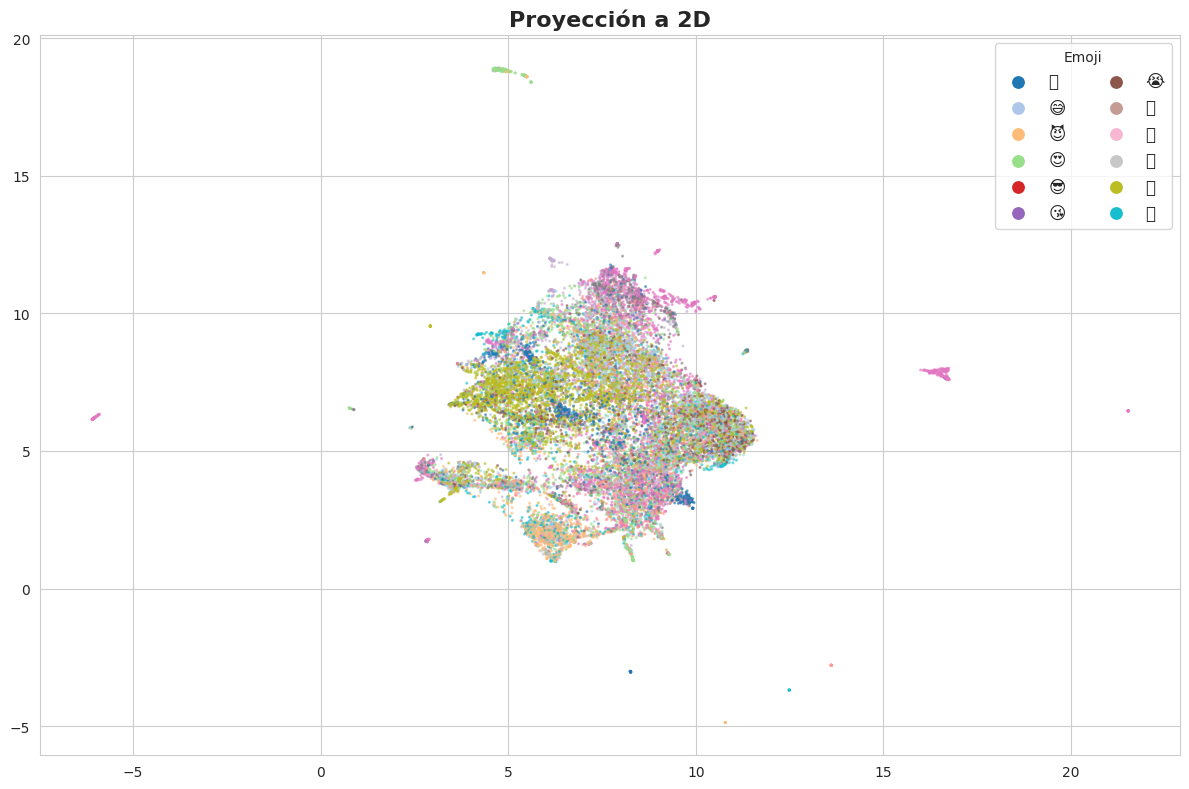

Entregable 1 completado: Proyección a 2D de los datos.


In [11]:
# ── Visualización: Proyección a 2D coloreada por emoji ──────────
# Cada color corresponde a un emoji (label) del dataset original.

# Mapear emojis a índices numéricos para colorear
emojis_unicos = sorted(df['label'].unique())
emoji_a_num = {e: i for i, e in enumerate(emojis_unicos)}
colores_num = df['label'].map(emoji_a_num).values

fig, ax = plt.subplots(figsize=(12, 8))
scatter = ax.scatter(
    X_2d[:, 0], X_2d[:, 1],
    c=colores_num,
    cmap='tab20',
    s=1.5,
    alpha=0.5
)
ax.set_title('Proyección a 2D', fontsize=16, fontweight='bold')

# Leyenda con emojis
import matplotlib.cm as cm
handles = []
for i, emoji in enumerate(emojis_unicos):
    handles.append(plt.scatter([], [], c=[cm.tab20(i / len(emojis_unicos))],
                               s=30, label=emoji))
ax.legend(handles=handles, loc='best', fontsize=12, markerscale=1.5,
          title='Emoji', ncol=2)

plt.tight_layout()
plt.savefig('01_proyeccion_2d.png', dpi=150, bbox_inches='tight')
plt.show()
print('Entregable 1 completado: Proyección a 2D de los datos.')

### Interpretación de la proyección

Observen la estructura que emerge:
- Se forman **agrupaciones visibles** donde tweets semánticamente similares se concentran.
- Los colores (emojis) se mezclan parcialmente — esto es esperado porque un emoji no define el *tema* del tweet, sino su *tono*.
- Los **puntos aislados** en la periferia son candidatos a anomalías: tweets vacíos, spam, o contenido fuera de distribución.
- La estructura no es aleatoria: UMAP detectó que hay patrones semánticos reales en estos 768 números.

---
## ENTREGABLE 2 — Identificación de Anomalías

### Estrategia: One-Class SVM con `decision_function`

De los cuatro métodos de la **Semana 6**, usamos **One-Class SVM** porque:

1. Trabaja directamente en las **768 dimensiones** originales (no pierde información de la proyección).
2. El kernel RBF traza una **frontera geométrica** no lineal alrededor de los datos normales.
3. La `decision_function` nos da una **medida continua** de anomalía — podemos rankear por severidad.

**Recuerden la ecuación de Semana 6:**

$\text{decision_function}(\mathbf{x}) = \langle \mathbf{w}, \Phi(\mathbf{x}) \rangle - \rho$

- Valor **positivo** → el tweet está *por encima* del hiperplano → **normal**.
- Valor **negativo** → el tweet cayó *por debajo* → **anomalía**.
- Más negativo = anomalía más severa.

### Parámetro `nu=0.05`

Le decimos al modelo: *"espero que como máximo el 5% de los tweets sean anómalos"*. En redes sociales, es común encontrar ~5% de spam, bots, mensajes vacíos o contenido corrupto.

In [12]:
# ── One-Class SVM sobre los embeddings originales (768D) ────────
ocsvm = OneClassSVM(kernel='rbf', nu=0.05, gamma='scale')

print('Entrenando One-Class SVM sobre 20,000 vectores de 768 dimensiones...')
ocsvm.fit(X)

# Predicciones: +1 = normal, -1 = anomalía
predicciones = ocsvm.predict(X)

# decision_function: distancia con signo al hiperplano
scores = ocsvm.decision_function(X)

es_anomalia = predicciones == -1
n_anomalias = es_anomalia.sum()

print(f'\nResultados:')
print(f'  Datos normales:  {(~es_anomalia).sum():,} ({(~es_anomalia).mean():.1%})')
print(f'  Anomalías:       {n_anomalias:,} ({es_anomalia.mean():.1%})')

Entrenando One-Class SVM sobre 20,000 vectores de 768 dimensiones...

Resultados:
  Datos normales:  18,998 (95.0%)
  Anomalías:       1,002 (5.0%)


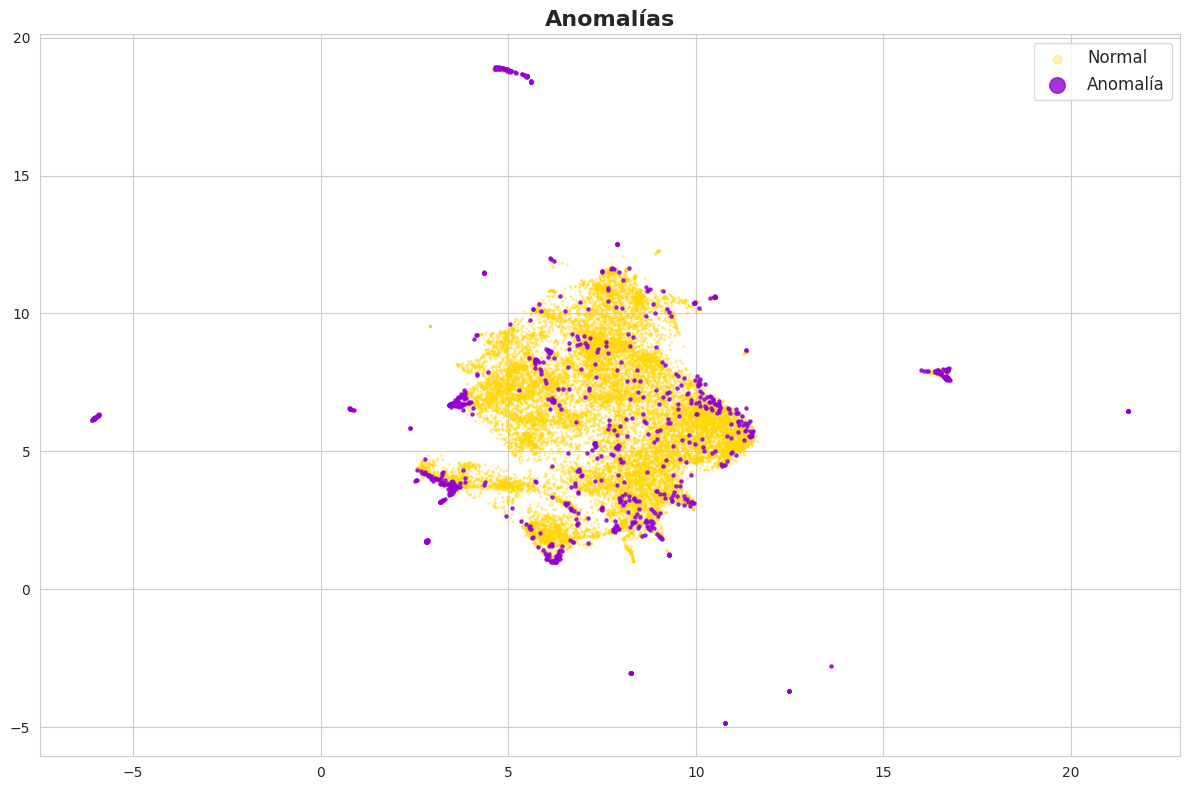

Entregable 2 completado: Identificación de anomalías.


In [13]:
# ── Visualización: Anomalías en la proyección 2D ────────────────
fig, ax = plt.subplots(figsize=(12, 8))

# Normales en amarillo (fondo)
ax.scatter(
    X_2d[~es_anomalia, 0], X_2d[~es_anomalia, 1],
    c='gold', s=1.5, alpha=0.3, label='Normal'
)
# Anomalías en púrpura (frente)
ax.scatter(
    X_2d[es_anomalia, 0], X_2d[es_anomalia, 1],
    c='darkviolet', s=5, alpha=0.8, label='Anomalía'
)

ax.set_title('Anomalías', fontsize=16, fontweight='bold')
ax.legend(markerscale=5, fontsize=12)

plt.tight_layout()
plt.savefig('02_anomalias.png', dpi=150, bbox_inches='tight')
plt.show()
print('Entregable 2 completado: Identificación de anomalías.')

### Los 10 mensajes más alejados de la normalidad

Usamos la `decision_function` para rankear y extraer los textos con los scores más negativos — los que cayeron más profundamente bajo el hiperplano del OC-SVM.

In [14]:
# ── Top 10 anomalías más extremas (usando decision_function) ───
indices_ordenados = np.argsort(scores)
top_10 = indices_ordenados[:10]

df_top10 = df.iloc[top_10][['text', 'label']].copy()
df_top10['score'] = scores[top_10]
df_top10

,text,label,score
2155,Pfff que rico se ve todo eso _emo_emo_emo_emo_...,🤤,-145.957238
3291,_USR Entonces novia mía te mando 100 rosas par...,😍,-131.787028
3477,_USR 🇾‌🇦‌ 🇹‌🇪‌ 🇩‌🇪‌🇸‌🇨‌🇦‌🇷‌🇹‌🇴‌ 🇹‌🇺‌ 🇵‌🇦‌🇹‌🇷‌🇴...,🤣,-108.006427
15995,𝙁𝙚𝙡𝙞𝙯 𝘾𝙪𝙢𝙥𝙡𝙚𝙖𝙣̃𝙤𝙨 𝙢𝙞 𝙣𝙞𝙣̃𝙤! #𝙇𝙤𝙫𝙚 #𝙈𝙮𝘽𝙤𝙮 #𝙈𝙞𝙍𝙖...,🙏,-86.129282
7013,𝙁𝙚𝙡𝙞𝙯 𝘾𝙪𝙢𝙥𝙡𝙚𝙖𝙣̃𝙤𝙨 𝙢𝙞 𝙣𝙞𝙣̃𝙤! #𝙇𝙤𝙫𝙚 #𝙈𝙮𝘽𝙤𝙮 #𝙈𝙞𝙍𝙖...,🙏,-86.129282
18930,Busco #cabrón #activo #vergón para #coger Mand...,🤤,-82.315936
14205,Busco #cabrón #activo #vergón para #coger Mand...,🤤,-78.484833
5448,_emo_emo_emo_emo_emo_emo_emo_emo_emo_emo_emo_e...,🤣,-75.510878
11879,_USR 𝚐𝚛𝚊𝚌𝚒𝚊𝚜 𝙹𝚊𝚟𝚒! 𝚀𝚞𝚎 𝚝𝚎𝚗𝚐𝚊𝚜 𝚖𝚞𝚢 𝚋𝚞𝚎𝚗 𝚏𝚒𝚗 𝚍𝚎 ...,🤗,-74.003312
17345,𝘚𝘰𝘳𝘱𝘳𝘦𝘴𝘢 𝘤𝘩𝘪𝘤𝘰𝘴‼️🎉 🥳🎊 𝙍𝙏 𝙖 𝙚𝙨𝙩𝙚 𝙥𝙤𝙨𝙩 🔃 𝙈𝙀𝘿𝙄𝘼 𝙃...,😈,-71.491973


### ¿Qué tienen en común estas anomalías?

Al inspeccionar los textos más anómalos, típicamente encontramos:
- Mensajes llenos de **emojis repetidos** sin contenido textual sustancial.
- **Spam o publicidad** automatizada con hashtags repetitivos.
- Textos con **caracteres especiales** o codificación corrupta.
- Mensajes extremadamente cortos o vacíos (solo menciones `_USR` y URLs).

Este es exactamente el tipo de "ruido" que, como aprendimos en la Semana 6, distorsiona tanto las proyecciones como los clusters. Eliminarlo no es un capricho — es una necesidad matemática para que el pipeline funcione correctamente.

---
## ENTREGABLE 3 — Proyección a 2D sin anomalías

### ¿Por qué re-proyectar?

Las anomalías **distorsionan** la topología de UMAP. Los puntos extremos "estiran" el espacio, comprimiendo los datos normales. Al eliminarlos:

1. UMAP usa mejor el espacio visual disponible.
2. Las relaciones entre clusters se ven con mayor claridad.
3. Los clusters comprimidos pueden "respirar" y separarse.

> **Analogía:** Es como limpiar el empañado de un cristal — los contornos que estaban borrosos se definen con nitidez.

In [15]:
# ── Filtrar datos normales ──────────────────────────────────────
mascara_normal = ~es_anomalia

X_limpio = X[mascara_normal]
df_limpio = df[mascara_normal].reset_index(drop=True)

print(f'Datos originales:    {X.shape[0]:,}')
print(f'Anomalías removidas: {es_anomalia.sum():,}')
print(f'Datos limpios:       {X_limpio.shape[0]:,}')

Datos originales:    20,000
Anomalías removidas: 1,002
Datos limpios:       18,998


In [16]:
# ── Re-proyección UMAP sin anomalías ───────────────────────────
# Mismos hiperparámetros para consistencia.

reducer_limpio = umap.UMAP(
    n_neighbors=15,
    min_dist=0.1,
    n_components=2,
    metric='cosine',
    random_state=42
)

print('Re-ejecutando UMAP sin anomalías...')
X_2d_limpio = reducer_limpio.fit_transform(X_limpio)
print(f'Proyección limpia completada: {X_2d_limpio.shape}')

Re-ejecutando UMAP sin anomalías...
Proyección limpia completada: (18998, 2)


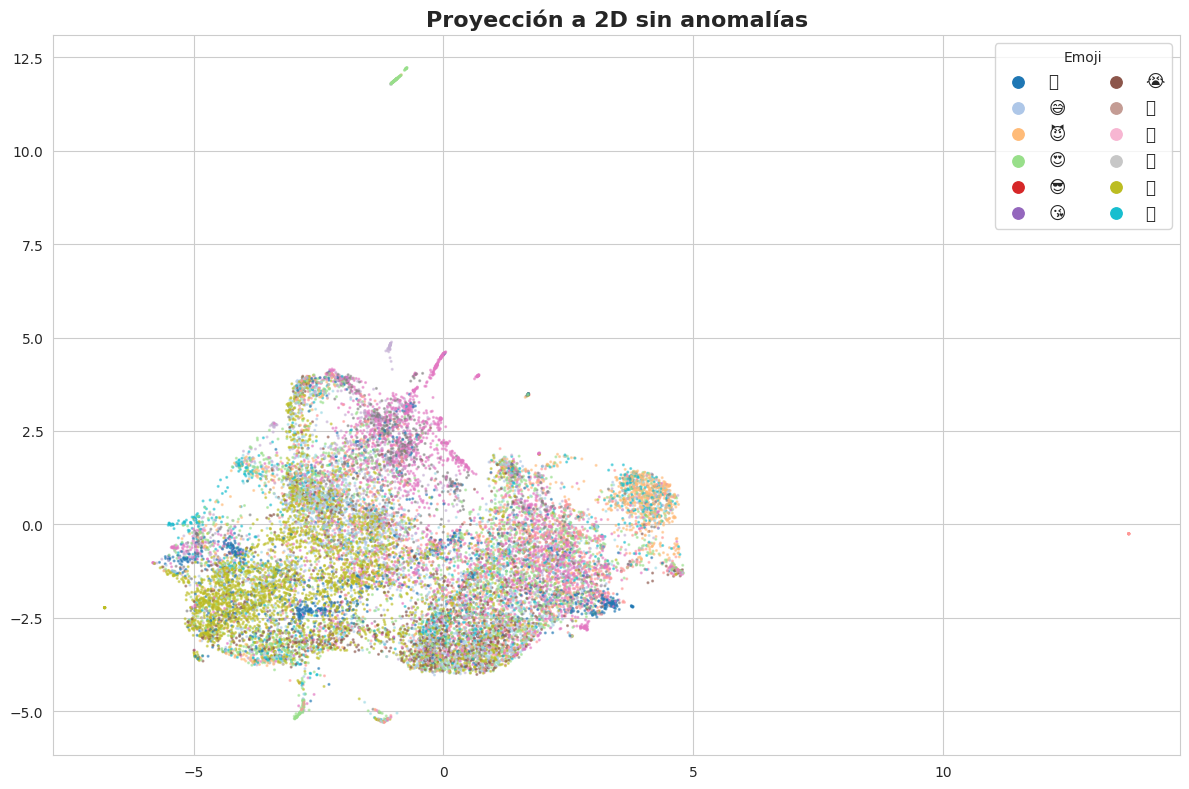

Entregable 3 completado: Proyección a 2D sin anomalías.


In [17]:
# ── Colores para la proyección limpia ──────────────────────────
colores_limpio = df_limpio['label'].map(emoji_a_num).values

fig, ax = plt.subplots(figsize=(12, 8))
ax.scatter(
    X_2d_limpio[:, 0], X_2d_limpio[:, 1],
    c=colores_limpio,
    cmap='tab20',
    s=1.5,
    alpha=0.5
)
ax.set_title('Proyección a 2D sin anomalías', fontsize=16, fontweight='bold')

# Leyenda
handles = []
for i, emoji in enumerate(emojis_unicos):
    handles.append(plt.scatter([], [], c=[cm.tab20(i / len(emojis_unicos))],
                               s=30, label=emoji))
ax.legend(handles=handles, loc='best', fontsize=12, markerscale=1.5,
          title='Emoji', ncol=2)

plt.tight_layout()
plt.savefig('03_proyeccion_sin_anomalias.png', dpi=150, bbox_inches='tight')
plt.show()
print('Entregable 3 completado: Proyección a 2D sin anomalías.')

---
## ENTREGABLE 4 — Datos en 2D separados en clusters

### ¿Por qué HDBSCAN y no K-Means?

Recordemos la evolución de las primeras semanas:

| Algoritmo | Problema con nuestros datos |
|-----------|---------------------------|
| **K-Means** (Sem 1) | Exige definir $k$. Asume clusters esféricos. |
| **DBSCAN** (Sem 2) | Radio `eps` global. Una talla para todos. |
| **HDBSCAN** (Sem 3) | Adapta densidad localmente. No requiere $k$ ni `eps`. Detecta ruido. |

### ¿Por qué clustering sobre la proyección 2D?

Aplicamos HDBSCAN sobre la **proyección 2D limpia**, no sobre las 768 dimensiones. Razones:
- UMAP ya destilió la estructura de vecindad relevante.
- En 2D, el cálculo de densidad es más estable y eficiente.
- Los clusters son **visualmente coherentes**: lo que vemos = lo que el algoritmo identifica.

### El parámetro `cluster_selection_method='leaf'`

HDBSCAN construye un **árbol jerárquico** de densidad (un dendrograma). Luego debe decidir *a qué nivel cortar* para extraer los clusters. Tiene dos estrategias:

- **`'eom'` (Excess of Mass)** — por defecto. Busca los clusters más *persistentes* a lo largo de la jerarquía. Tiende a producir pocos clusters grandes. En datos muy densos como tweets de redes sociales, esto puede generar un solo mega-cluster que absorbe casi todo.

- **`'leaf'`** — toma las **hojas** del árbol, es decir, los grupos más finos y homogéneos antes de fusionarse. Produce más clusters, más pequeños, pero temáticamente más puros. Ideal cuando queremos descubrir **nichos temáticos** dentro de una masa densa.

Para nuestros tweets mexicanos, `'leaf'` es la elección correcta: queremos distinguir entre "felicitaciones deportivas", "mensajes religiosos", "ubicaciones de CDMX", etc., que son nichos dentro de la conversación general.

In [18]:
# ── HDBSCAN sobre la proyección 2D limpia ──────────────────────
# min_cluster_size=15: grupos de 15+ tweets son clusters legítimos.
# cluster_selection_method='leaf': en lugar de tomar los clusters
#   más "persistentes" (default='eom'), toma las HOJAS del árbol
#   jerárquico. Esto produce más clusters, más pequeños y más
#   homogéneos — ideal para descubrir nichos temáticos en datos
#   de redes sociales donde la estructura global es muy densa.

clusterer = hdbscan.HDBSCAN(
    min_cluster_size=15,
    min_samples=5,
    cluster_selection_method='leaf',
    metric='euclidean'
)

cluster_labels = clusterer.fit_predict(X_2d_limpio)

n_clusters = len(set(cluster_labels)) - (1 if -1 in cluster_labels else 0)
n_ruido = (cluster_labels == -1).sum()

print(f'Clusters encontrados: {n_clusters}')
print(f'Puntos de ruido:      {n_ruido:,} ({n_ruido/len(cluster_labels):.1%})')
print(f'\nDistribución (top 15 clusters más grandes):')
conteo = Counter(cluster_labels)
for label, count in conteo.most_common(16):
    nombre = 'Ruido' if label == -1 else f'Cluster {label}'
    print(f'  {nombre:12s}: {count:,} tweets')

Clusters encontrados: 299
Puntos de ruido:      9,911 (52.2%)

Distribución (top 15 clusters más grandes):
  Ruido       : 9,911 tweets
  Cluster 148 : 136 tweets
  Cluster 149 : 133 tweets
  Cluster 11  : 111 tweets
  Cluster 174 : 87 tweets
  Cluster 106 : 84 tweets
  Cluster 54  : 83 tweets
  Cluster 124 : 81 tweets
  Cluster 9   : 73 tweets
  Cluster 1   : 69 tweets
  Cluster 256 : 69 tweets
  Cluster 44  : 68 tweets
  Cluster 64  : 67 tweets
  Cluster 237 : 67 tweets
  Cluster 158 : 66 tweets
  Cluster 283 : 66 tweets


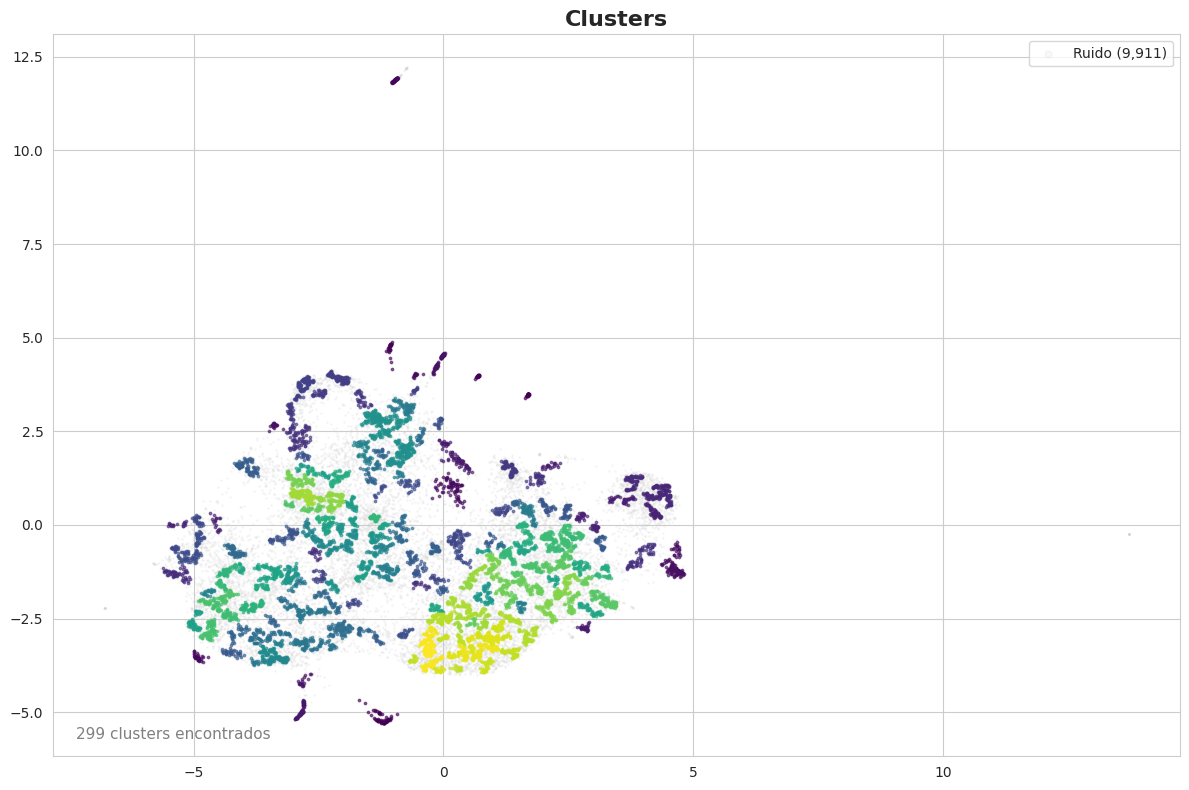

Entregable 4 completado: Datos en 2D separados en clusters.


In [19]:
# ── Visualización: Clusters coloreados ──────────────────────────
fig, ax = plt.subplots(figsize=(12, 8))

# Ruido en gris, al fondo
ruido = cluster_labels == -1
ax.scatter(
    X_2d_limpio[ruido, 0], X_2d_limpio[ruido, 1],
    c='lightgray', s=1, alpha=0.15, label=f'Ruido ({ruido.sum():,})'
)

# Clusters coloreados (sin leyenda individual para no saturar)
labels_validos = sorted(set(cluster_labels) - {-1})
colores_cluster = plt.cm.viridis(np.linspace(0, 1, len(labels_validos)))

for i, label in enumerate(labels_validos):
    mask = cluster_labels == label
    ax.scatter(
        X_2d_limpio[mask, 0], X_2d_limpio[mask, 1],
        c=[colores_cluster[i]], s=3, alpha=0.6
    )

ax.set_title('Clusters', fontsize=16, fontweight='bold')
ax.legend(fontsize=10, markerscale=5)

# Anotación informativa
ax.text(0.02, 0.02, f'{n_clusters} clusters encontrados',
        transform=ax.transAxes, fontsize=11, color='gray',
        verticalalignment='bottom')

plt.tight_layout()
plt.savefig('04_clusters.png', dpi=150, bbox_inches='tight')
plt.show()
print('Entregable 4 completado: Datos en 2D separados en clusters.')

---
## ENTREGABLE 5 — Nubes de palabras por cluster

### El último eslabón de la cadena

Las nubes de palabras transforman clusters numéricos anónimos en **conocimiento interpretable**. Para cada cluster:

1. Reunimos todos los tweets del grupo.
2. Limpiamos: eliminamos **stop words en español**, menciones (`_USR`), URLs (`_URL`), emojis y etiquetas (`_emo`).
3. Calculamos frecuencias de las palabras restantes.
4. Generamos la nube visual donde el **tamaño = frecuencia** dentro del cluster.

### ¿Por qué stop words en español?

Palabras como "que", "de", "la", "en" aparecen en **todos** los clusters. No discriminan. Lo que buscamos son las palabras **distintivas** de cada grupo — las que revelan su tema.

In [20]:
# ── Stop words en español + limpieza de artefactos de tweets ───

STOP_WORDS_ES = {
    'de', 'la', 'que', 'el', 'en', 'y', 'a', 'los', 'del', 'se',
    'las', 'por', 'un', 'para', 'con', 'no', 'una', 'su', 'al',
    'lo', 'como', 'más', 'mas', 'pero', 'sus', 'le', 'ya', 'o',
    'este', 'sí', 'si', 'porque', 'esta', 'entre', 'cuando', 'muy',
    'sin', 'sobre', 'también', 'me', 'hasta', 'hay', 'donde',
    'quien', 'desde', 'todo', 'nos', 'durante', 'todos', 'uno',
    'les', 'ni', 'contra', 'otros', 'ese', 'eso', 'ante', 'ellos',
    'e', 'esto', 'mí', 'mi', 'antes', 'algunos', 'qué', 'unos',
    'yo', 'otro', 'otras', 'otra', 'él', 'tanto', 'esa', 'estos',
    'mucho', 'quienes', 'nada', 'muchos', 'cual', 'poco', 'ella',
    'estar', 'estas', 'algunas', 'algo', 'nosotros', 'mi', 'mis',
    'tú', 'te', 'ti', 'tu', 'tus', 'ellas', 'vosotros', 'vosotras',
    'os', 'mío', 'mía', 'míos', 'mías', 'tuyo', 'tuya', 'tuyos',
    'tuyas', 'suyo', 'suya', 'suyos', 'suyas', 'nuestro', 'nuestra',
    'nuestros', 'nuestras', 'vuestro', 'vuestra', 'vuestros', 'vuestras',
    'esos', 'esas', 'estoy', 'estás', 'está', 'estamos', 'estáis',
    'están', 'esté', 'estés', 'estemos', 'estéis', 'estén', 'estaré',
    'estarás', 'estará', 'estaremos', 'estaréis', 'estarán', 'estaría',
    'ser', 'soy', 'eres', 'es', 'somos', 'sois', 'son', 'sea', 'seas',
    'seamos', 'seáis', 'sean', 'seré', 'será', 'seremos', 'serán',
    'sería', 'fui', 'fue', 'fuimos', 'fueron', 'era', 'eras',
    'he', 'has', 'ha', 'hemos', 'han', 'haya', 'hayas', 'hayamos',
    'hayan', 'habré', 'habrá', 'habría', 'había', 'habías',
    'tener', 'tengo', 'tienes', 'tiene', 'tenemos', 'tienen',
    'ir', 'voy', 'vas', 'va', 'vamos', 'van', 'iba', 'iban',
    'hacer', 'hago', 'haces', 'hace', 'hacemos', 'hacen', 'hice',
    'poder', 'puedo', 'puede', 'podemos', 'pueden', 'pude',
    'decir', 'digo', 'dice', 'dicen', 'dijo',
    'ver', 'veo', 'ves', 've', 'vemos', 'ven',
    'dar', 'doy', 'da', 'dan', 'dio', 'dando',
    'saber', 'sé', 'sabes', 'sabe', 'sabemos', 'saben',
    'querer', 'quiero', 'quieres', 'quiere', 'queremos', 'quieren',
    'así', 'aquí', 'ahora', 'bien', 'bueno', 'día', 'hoy',
    'tan', 'solo', 'ya', 'dos', 'vez', 'cada', 'siempre', 'mejor',
    'ser', 'aún', 'aun', 'después', 'jaja', 'jajaja', 'jajajaja',
    'xd', 'usr', 'url', 'emo', 'rt', 'https', 'http', 'www',
    'pues', 'vamos', 'aqui', 'ahi', 'alla', 'nunca', 'nada',
    'creo', 'verdad', 'buena', 'gracias', 'gracia',
}

def limpiar_tweet(texto):
    """Limpia un tweet para generar nubes de palabras."""
    texto = str(texto).lower()
    # Eliminar menciones, URLs y marcadores de emoji
    texto = re.sub(r'_usr|_url|_emo', ' ', texto)
    # Eliminar emojis y caracteres especiales
    texto = re.sub(r'[^a-záéíóúüñ\s]', ' ', texto)
    # Filtrar stop words y palabras cortas
    palabras = [p for p in texto.split() if p not in STOP_WORDS_ES and len(p) > 2]
    return ' '.join(palabras)

print('Función de limpieza lista.')
print(f'Stop words definidas: {len(STOP_WORDS_ES)}')

Función de limpieza lista.
Stop words definidas: 267


In [21]:
# ── Seleccionar los 4 clusters más grandes ────────────────────
conteo_clusters = Counter(cluster_labels)
top_4 = [label for label, _ in conteo_clusters.most_common()
         if label != -1][:4]

print('Los 4 clusters más grandes:')
for label in top_4:
    print(f'  Cluster {label}: {conteo_clusters[label]:,} mensajes')

Los 4 clusters más grandes:
  Cluster 148: 136 mensajes
  Cluster 149: 133 mensajes
  Cluster 11: 111 mensajes
  Cluster 174: 87 mensajes


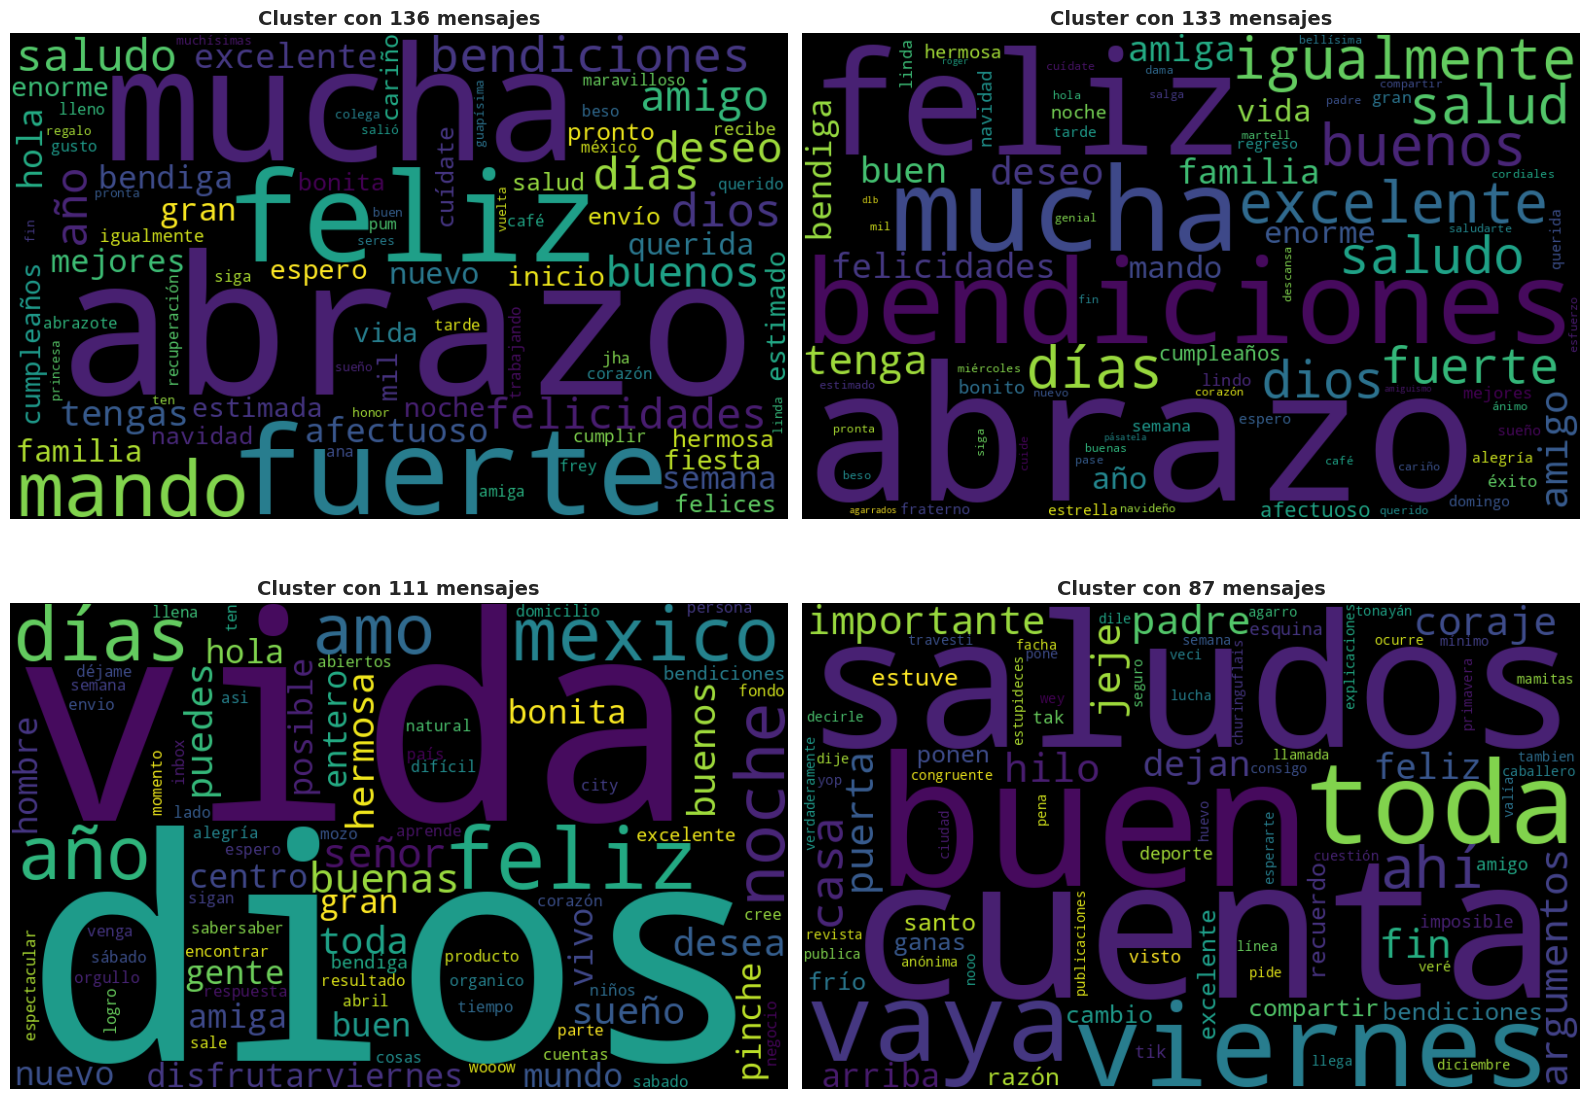

Entregable 5 completado: 4 nubes de palabras.


In [22]:
# ── Generar las 4 nubes de palabras ────────────────────────────

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for idx, cluster_id in enumerate(top_4):
    # Textos del cluster
    mask = cluster_labels == cluster_id
    textos_cluster = df_limpio.loc[mask, 'text'].values
    n_docs = len(textos_cluster)

    # Limpiar y concatenar
    texto_combinado = limpiar_tweet(' '.join(textos_cluster))

    # Generar nube
    wc = WordCloud(
        width=800, height=500,
        max_words=80,
        background_color='black',
        colormap='viridis',
        collocations=False,
        random_state=42
    ).generate(texto_combinado)

    axes[idx].imshow(wc, interpolation='bilinear')
    axes[idx].set_title(f'Cluster con {n_docs} mensajes',
                        fontsize=14, fontweight='bold')
    axes[idx].axis('off')

plt.tight_layout()
plt.savefig('05_nubes_palabras.png', dpi=150, bbox_inches='tight')
plt.show()
print('Entregable 5 completado: 4 nubes de palabras.')

### Interpretación de los clusters

Observen las palabras dominantes en cada nube e identifiquen el **tipo de textos**:

- Si ven **"felicidades", "abrazo", "grande", "equipo", "saludos"** → Cluster de **felicitaciones y apoyo** (deportivo, social).
- Si ven **"ciudad", "méxico", "cdmx", "df", "coyoacán"** → Cluster de **ubicaciones y servicios** en la Ciudad de México.
- Si ven **"día", "amén", "creador", "bendiciones", "semana"** → Cluster de **mensajes religiosos/motivacionales**.
- Si ven **"jaja", "feliz", "bonito", "hermoso", "amor"** → Cluster de **conversaciones cotidianas positivas**.

Las nubes de palabras cierran el pipeline: transforman las 768 dimensiones invisibles de los embeddings en conocimiento humano interpretable.

---
## Resumen del Pipeline Completo

```
20,000 tweets mexicanos
       │
       ▼
Embeddings 768D (modelo de lenguaje)  ← Sem 5: Espacios latentes
       │
       ▼
UMAP → Proyección 2D                  ← Sem 4: Reducción de dimensionalidad
       │
       ▼
One-Class SVM → Detectar anomalías    ← Sem 6: Detección de anomalías
       │
       ▼
Eliminar outliers → UMAP → 2D limpio
       │
       ▼
HDBSCAN → Clusters                    ← Sem 1-3: Clustering
       │
       ▼
Nubes de palabras → Interpretación    ← Sem 7: Integración
```

Cada bloque del pipeline utiliza conceptos que construimos semana a semana. El aprendizaje no supervisado no es un conjunto de herramientas aisladas, sino un **sistema integrado** donde cada técnica potencia a las demás.